# Fleet Maintenance Planner: FD001 exploration and modelling

Goal: predict the remaining useful life (RUL) of turbofan engines from sensor data (NASA C-MAPSS, subset FD001).

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_val_score

## 1. Load the data

Columns: engine id, cycle, 3 operational settings, 21 sensors. Files have no header.

In [44]:
cols = ["unit", "cycle", "set1", "set2", "set3"] + [f"s{i}" for i in range(1, 22)]
train = pd.read_csv("../data/train_FD001.txt", sep=r"\s+", header=None, names=cols)
test = pd.read_csv("../data/test_FD001.txt", sep=r"\s+", header=None, names=cols)
rul_test = pd.read_csv("../data/RUL_FD001.txt", header=None, names=["RUL"])

print(train.shape, test.shape, rul_test.shape)

(20631, 26) (13096, 26) (100, 1)


In [45]:
train.head()

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Target: remaining useful life (RUL)

RUL = cycles left before failure. Capped at 125 because wear is not detectable early in an engine's life.

In [46]:
train["RUL"] = train.groupby("unit")["cycle"].transform("max") - train["cycle"]
train["RUL"] = train["RUL"].clip(upper=125)
train[["unit", "cycle", "RUL"]].head(10)

,unit,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


## 3. Remove constant sensors

Sensors that never vary carry no information about wear.

In [47]:
train.describe().T[["mean", "std"]]

,mean,std
unit,51.506568,2.922763e+01
cycle,108.807862,6.888099e+01
set1,-0.000009,2.187313e-03
set2,0.000002,2.930621e-04
set3,100.000000,0.000000e+00
s1,518.670000,0.000000e+00
s2,642.680934,5.000533e-01
s3,1590.523119,6.131150e+00
s4,1408.933782,9.000605e+00
s5,14.620000,5.329200e-15


In [48]:
constant = [c for c in train.columns if train[c].std() < 1e-4]
print(constant)
train = train.drop(columns=constant)
test = test.drop(columns=constant)

['set3', 's1', 's5', 's10', 's16', 's18', 's19']


## 4. Sensor trends as engines wear out

Five engines per sensor; failure is on the right.

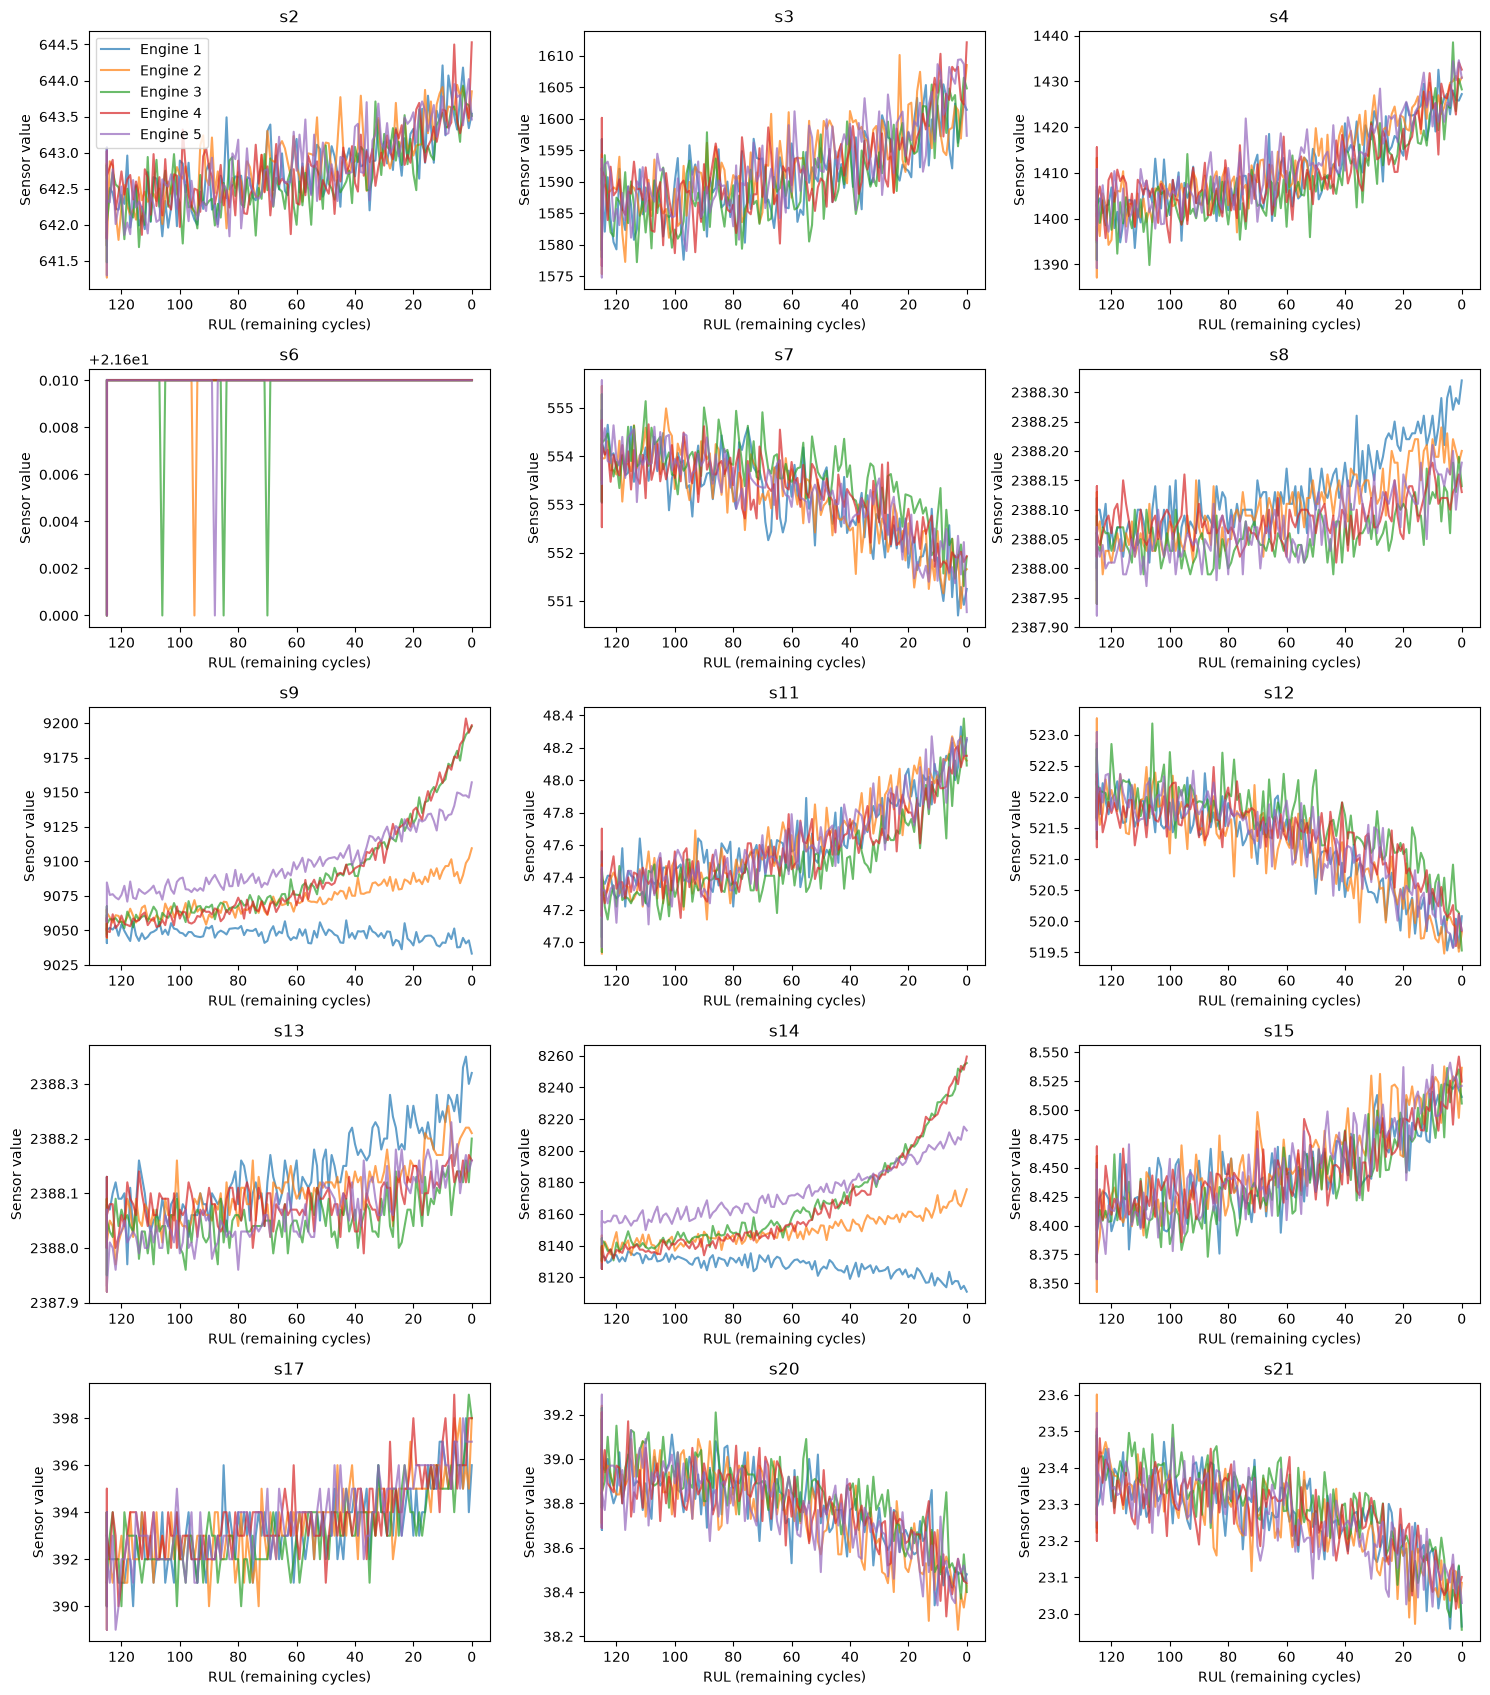

In [49]:
sensors = [c for c in train.columns if c.startswith("s") and not c.startswith("set")]

fig, axes = plt.subplots(len(sensors) // 3 + 1, 3, figsize=(15, 20))
for ax, s in zip(axes.flat, sensors):
    for u in [1, 2, 3, 4, 5]:
        d = train[train["unit"] == u]
        ax.plot(d["RUL"], d[s], alpha=0.7, label=f"Engine {u}")
    ax.set_title(s)
    ax.set_xlabel("RUL (remaining cycles)")
    ax.set_ylabel("Sensor value")
    ax.invert_xaxis()

for ax in axes.flat[len(sensors):]:
    ax.set_visible(False)

axes.flat[0].legend()
plt.tight_layout()

## 5. Correlation with RUL and feature selection

The further from 0 (in either direction), the stronger the link with wear. Keep sensors with |correlation| > 0.5.

In [50]:
corr = train.corr()["RUL"].drop(["RUL", "unit", "cycle"]).sort_values()
features = [s for s in sensors if abs(corr[s]) > 0.5]
print(features)
corr

['s2', 's3', 's4', 's7', 's8', 's11', 's12', 's13', 's15', 's17', 's20', 's21']


s11    -0.775230
s4     -0.757157
s15    -0.720858
s17    -0.680829
s2     -0.678458
s3     -0.655030
s8     -0.624568
s13    -0.624034
s9     -0.462151
s14    -0.369753
s6     -0.108289
set2   -0.007091
set1   -0.005556
s20     0.704626
s21     0.707334
s7      0.733021
s12     0.748870
Name: RUL, dtype: float64

## 6. Evaluation tools

- **RMSE**: average error in cycles.
- **NASA score**: penalises late predictions (overestimating remaining life) more than early ones. Lower is better.

Test engines are evaluated at their last observed cycle, against `RUL_FD001.txt`.

In [51]:
y_true = rul_test["RUL"].clip(upper=125).values

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1))

def evaluate(model, test_df, feats):
    last = test_df.groupby("unit").last().reset_index()
    pred = model.predict(last[feats]).clip(0, 125)
    rmse = np.sqrt(np.mean((pred - y_true) ** 2))
    print(f"RMSE: {rmse:.1f} cycles | NASA score: {nasa_score(y_true, pred):.0f} | Mean error: {np.mean(pred - y_true):+.1f}")
    return last, pred

## 7. Baseline: linear regression on raw sensors

In [52]:
baseline = LinearRegression().fit(train[features], train["RUL"])
_ = evaluate(baseline, test, features)

RMSE: 21.3 cycles | NASA score: 1145 | Mean error: +4.1


**Baseline result (test):** RMSE 21.3 cycles, NASA score 1145.

*Early experiment:* random forest + 10-cycle rolling features gave RMSE 21.0 / NASA 2150 on test (mean error +5.1, too optimistic). From here on, models are compared with cross-validation instead of the test set, which is kept for the final evaluation only.

## 8. Rolling features

Sensors are noisy: add each sensor's mean and standard deviation over the last `window` cycles to capture the trend.

In [53]:
def add_rolling(df, cols, window=10):
    df = df.copy()
    g = df.groupby("unit")
    for c in cols:
        df[f"{c}_mean"] = g[c].transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f"{c}_std"] = g[c].transform(lambda x: x.rolling(window, min_periods=1).std()).fillna(0)
    return df

means = [f"{c}_mean" for c in features]
stds = [f"{c}_std" for c in features]

## 9. Cross-validation grouped by engine

5 folds split **by engine**, so cycles from the same engine never end up in both training and validation.

In [54]:
def cv_rmse(model, df, feats):
    scores = cross_val_score(
        model, df[feats], df["RUL"],
        groups=df["unit"], cv=GroupKFold(n_splits=5),
        scoring="neg_root_mean_squared_error",
    )
    return -scores.mean()

train_10 = add_rolling(train, features, 10)
print(f"Linear (base):    {cv_rmse(LinearRegression(), train, features):.1f}")
print(f"Linear + rolling: {cv_rmse(LinearRegression(), train_10, features + means + stds):.1f}")

Linear (base):    22.9
Linear + rolling: 21.4


## 10. Model and feature comparison

In [55]:
models = {
    "Linear": LinearRegression(),
    "Gradient boosting": HistGradientBoostingRegressor(random_state=42),
}

results = []
for window in [10, 20, 30]:
    tr = add_rolling(train, features, window)
    for feat_name, feats in [("means", features + means), ("means + std", features + means + stds)]:
        for model_name, model in models.items():
            results.append({"window": window, "features": feat_name, "model": model_name,
                            "cv_rmse": cv_rmse(model, tr, feats)})

pd.DataFrame(results).sort_values("cv_rmse")

,window,features,model,cv_rmse
11,30,means + std,Gradient boosting,18.074129
9,30,means,Gradient boosting,18.567762
5,20,means,Gradient boosting,19.179190
3,10,means + std,Gradient boosting,19.236333
7,20,means + std,Gradient boosting,19.245051
1,10,means,Gradient boosting,19.374582
10,30,means + std,Linear,20.277065
8,30,means,Linear,20.618085
6,20,means + std,Linear,20.973418
4,20,means,Linear,21.121566


Gradient boosting with means + std wins at every window, and larger windows help. Next: push the window further.

In [56]:
feats = features + means + stds
for window in [40, 50, 60, 80, 100]:
    tr = add_rolling(train, features, window)
    rmse = cv_rmse(HistGradientBoostingRegressor(random_state=42), tr, feats)
    print(f"Window {window}: {rmse:.1f}")

Window 40: 17.0
Window 50: 16.0
Window 60: 15.6
Window 80: 15.0
Window 100: 15.1


**Cross-validation summary:** CV RMSE drops from 22.9 (linear baseline) to 15.0 (gradient boosting, window 80). It plateaus after 80.

## 11. Length of test histories

Test series stop before failure; short histories could hurt large windows.

In [57]:
test.groupby("unit")["cycle"].max().describe()

count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64

## 12. Final evaluation on the test set

In [58]:
best_window = 80

train_b = add_rolling(train, features, best_window)
test_b = add_rolling(test, features, best_window)

gb = HistGradientBoostingRegressor(random_state=42).fit(train_b[feats], train_b["RUL"])
last, pred_gb = evaluate(gb, test_b, feats)

RMSE: 15.0 cycles | NASA score: 446 | Mean error: +1.6


Text(0.5, 1.0, 'Error vs length of engine history')

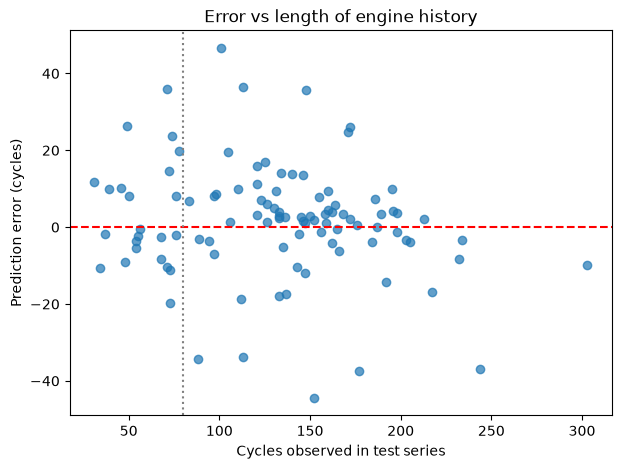

In [59]:
last["error"] = pred_gb - y_true

plt.figure(figsize=(7, 5))
plt.scatter(last["cycle"], last["error"], alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.axvline(best_window, color="grey", linestyle=":")
plt.xlabel("Cycles observed in test series")
plt.ylabel("Prediction error (cycles)")
plt.title("Error vs length of engine history")

In [60]:
last[["unit", "cycle", "error"]].reindex(last["error"].abs().sort_values(ascending=False).index).head(8)

,unit,cycle,error
78,79,101,46.620735
44,45,152,-44.460637
88,89,177,-37.484344
92,93,244,-36.866579
15,16,113,36.420367
66,67,71,35.841935
20,21,148,35.722854
74,75,88,-34.421449


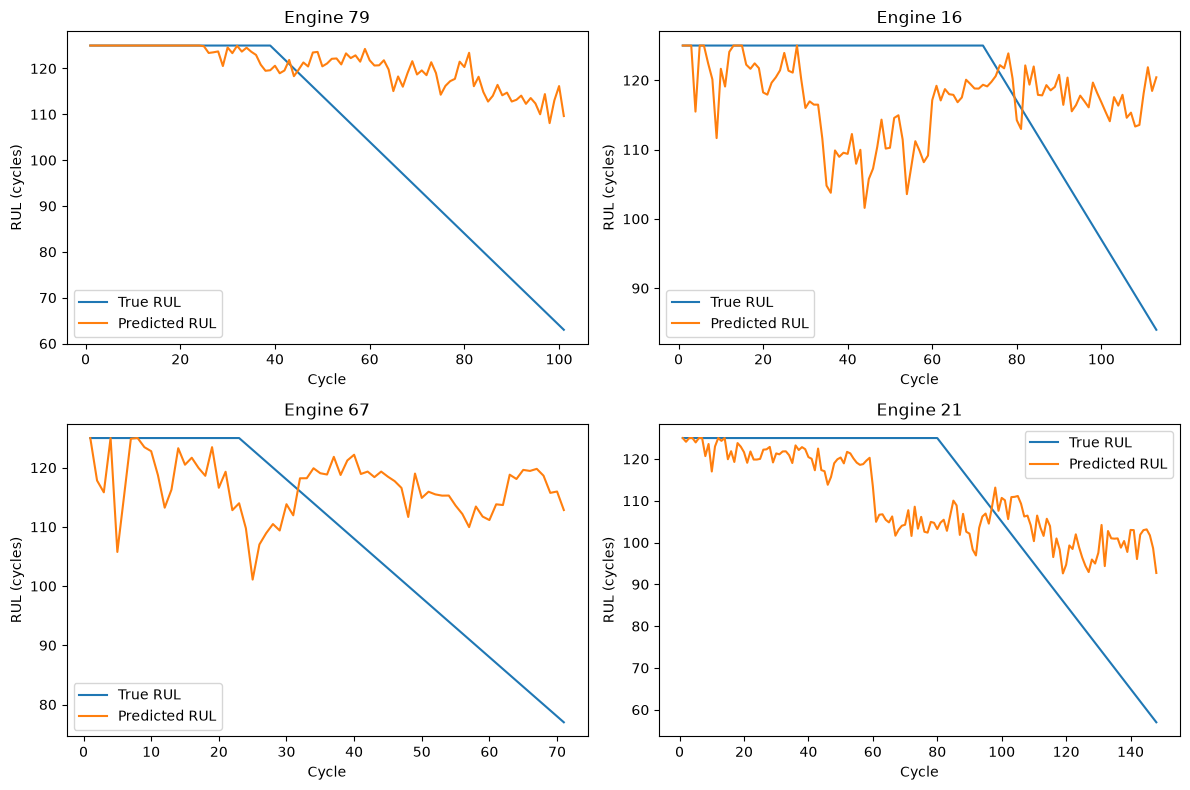

In [61]:
worst = [79, 16, 67, 21]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, u in zip(axes.flat, worst):
    d = test_b[test_b["unit"] == u]
    true_last = rul_test["RUL"].iloc[u - 1]
    true_rul = (true_last + d["cycle"].max() - d["cycle"]).clip(upper=125)
    ax.plot(d["cycle"], true_rul, label="True RUL")
    ax.plot(d["cycle"], gb.predict(d[feats]).clip(0, 125), label="Predicted RUL")
    ax.set_title(f"Engine {u}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL (cycles)")
    ax.legend()
plt.tight_layout()
plt.show()

## 13. Conclusions
